In [ ]:
# projektowanie algorytmów - lista 11, algorytmy grafowe, Oliwia Borkowska

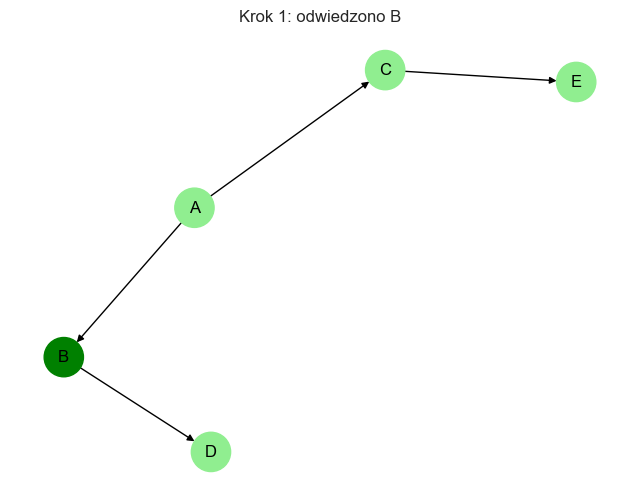

<Figure size 640x480 with 0 Axes>

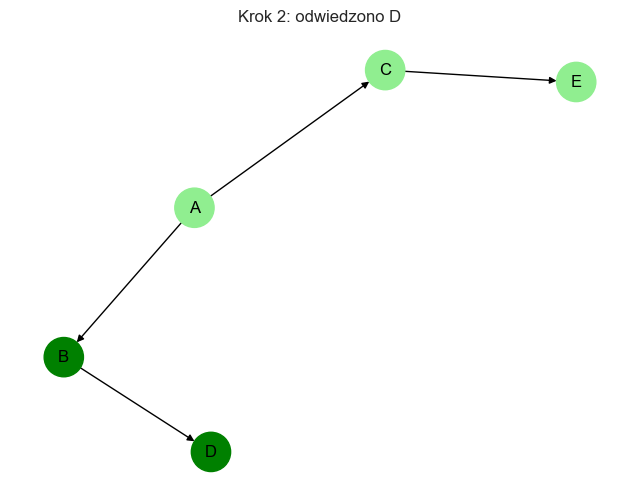

In [11]:
# Zadanie nr 1– przeszukiwanie w głąb
# Dla zadanego grafu wczytywanego z pliku zaimplementuj algorytm przeszukiwania w głąb.
# Procedurę przedstaw graficznie, krok po kroku.
# Wejście: plik z grafem, początkowy wierzchołek.
# Wyjście: wizualizacja.

import matplotlib.pyplot as plt
import networkx as nx
import time

# graf wczytany z pliku
def wczytaj_graf_z_pliku(nazwa_pliku):
    graf = {}
    with open(nazwa_pliku, 'r') as plik:
        for linia in plik:
            dane = linia.strip().split()
            if dane:
                graf[dane[0]] = dane[1:]
    return graf

# wizualizacja
def dfs_wizualizacja(graf, start):
    G = nx.DiGraph()
    for wierzcholek, sasiedzi in graf.items():
        for sasiad in sasiedzi:
            G.add_edge(wierzcholek, sasiad)

    odwiedzone = set()
    kroki = []

    def dfs(v): # przeszukiwanie w głąb
        odwiedzone.add(v)
        kroki.append((v, set(odwiedzone)))
        for sasiad in graf.get(v, []):
            if sasiad not in odwiedzone:
                dfs(sasiad)

    dfs(start)

    def hierarchic_layout(G, root):
        return nx.nx_agraph.graphviz_layout(G, prog='dot', root=root)

    try:
        pos = hierarchic_layout(G, start)
    except:
        pos = nx.spring_layout(G)

    for krok, (v, odw) in enumerate(kroki):
        plt.figure(figsize=(8, 6))
        plt.title(f"Krok {krok + 1}: odwiedzono {v}")
        kolory = ['green' if node in odw else 'lightgreen' for node in G.nodes()]
        nx.draw(G, pos, with_labels=True, node_color=kolory, node_size=800, arrows=True)
        plt.pause(1.5)
        plt.clf()
    plt.close()


plik = input("Podaj nazwę pliku z grafem (np. graf1.txt): ")
start = input("Podaj wierzchołek początkowy: ")

graf = wczytaj_graf_z_pliku(plik)
dfs_wizualizacja(graf, start)

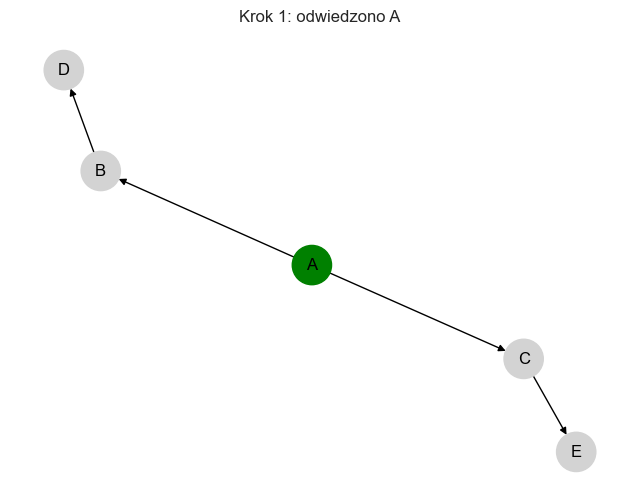

<Figure size 640x480 with 0 Axes>

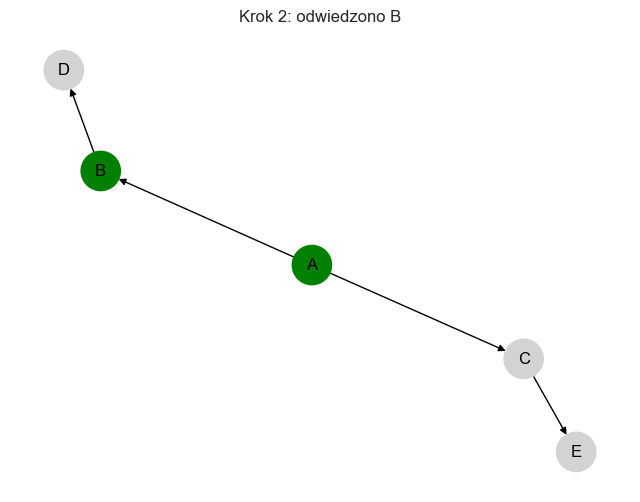

<Figure size 640x480 with 0 Axes>

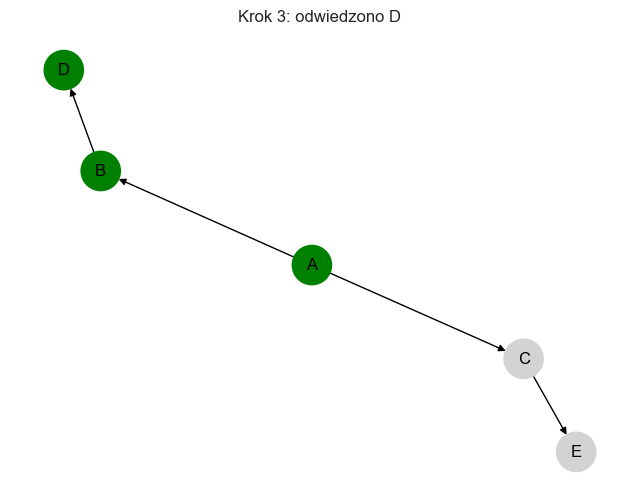

<Figure size 640x480 with 0 Axes>

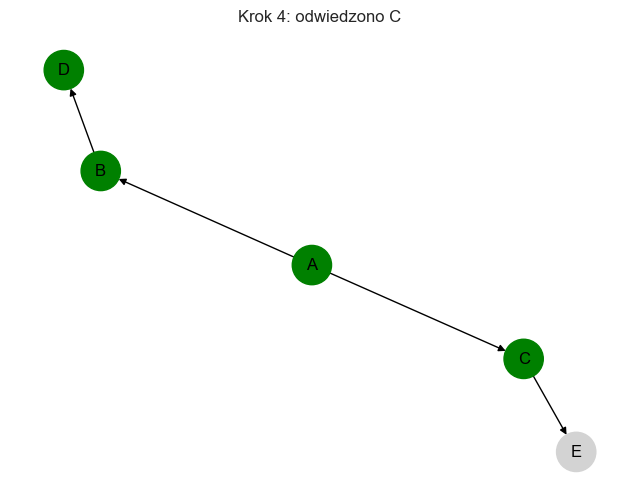

<Figure size 640x480 with 0 Axes>

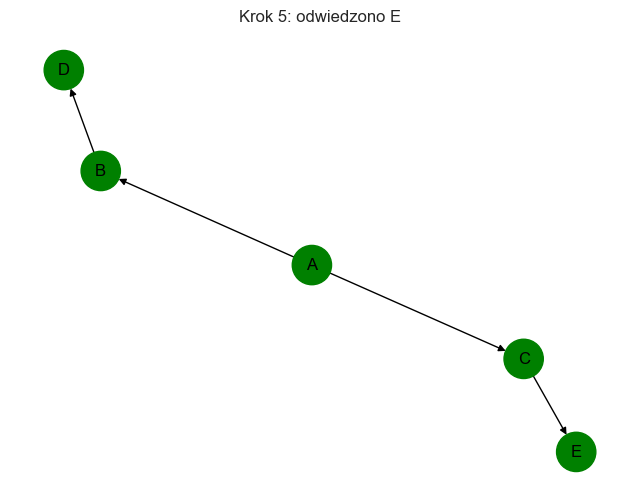

In [12]:
# Zadanie nr 2– pełne przeszukiwanie w głąb 
# Dla zadanego grafu wczytywanego z pliku zaimplementuj algorytm pełnego przeszukiwania w głąb.
# Procedurę przedstaw graficznie, krok po kroku.
# Wejście: plik z grafem.
# Wyjście: wizualizacja.

import matplotlib.pyplot as plt
import networkx as nx
import time

# graf wczytany z pliku
def wczytaj_graf_z_pliku(nazwa_pliku):
    graf = {}
    with open(nazwa_pliku, 'r') as plik:
        for linia in plik:
            dane = linia.strip().split()
            if dane:
                graf[dane[0]] = dane[1:]
    return graf

def pelne_dfs_wizualizacja(graf): # pełne przeszukiwanie w głąb
    G = nx.DiGraph()
    for wierzcholek, sasiedzi in graf.items():
        for sasiad in sasiedzi:
            G.add_edge(wierzcholek, sasiad)

    odwiedzone = set()
    kroki = []

    def dfs(v):
        odwiedzone.add(v)
        kroki.append((v, set(odwiedzone)))
        for sasiad in graf.get(v, []):
            if sasiad not in odwiedzone:
                dfs(sasiad)

    for wierzcholek in graf:
        if wierzcholek not in odwiedzone:
            dfs(wierzcholek)

    def hierarchic_layout(G):
        try:
            return nx.nx_agraph.graphviz_layout(G, prog='dot')
        except:
            return nx.spring_layout(G)

    pos = hierarchic_layout(G)

    for krok, (v, odw) in enumerate(kroki):
        plt.figure(figsize=(8, 6))
        plt.title(f"Krok {krok + 1}: odwiedzono {v}")
        kolory = ['green' if node in odw else 'lightgray' for node in G.nodes()]
        nx.draw(G, pos, with_labels=True, node_color=kolory, node_size=800, arrows=True)
        plt.pause(1.5)
        plt.clf()
    plt.close()

plik = input("Podaj nazwę pliku z grafem (np. graf1.txt): ")
graf = wczytaj_graf_z_pliku(plik)
pelne_dfs_wizualizacja(graf)

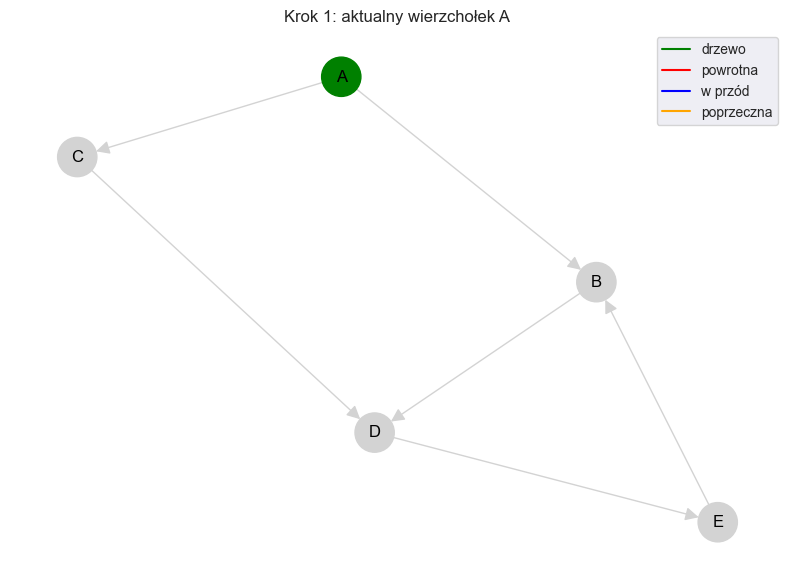

<Figure size 640x480 with 0 Axes>

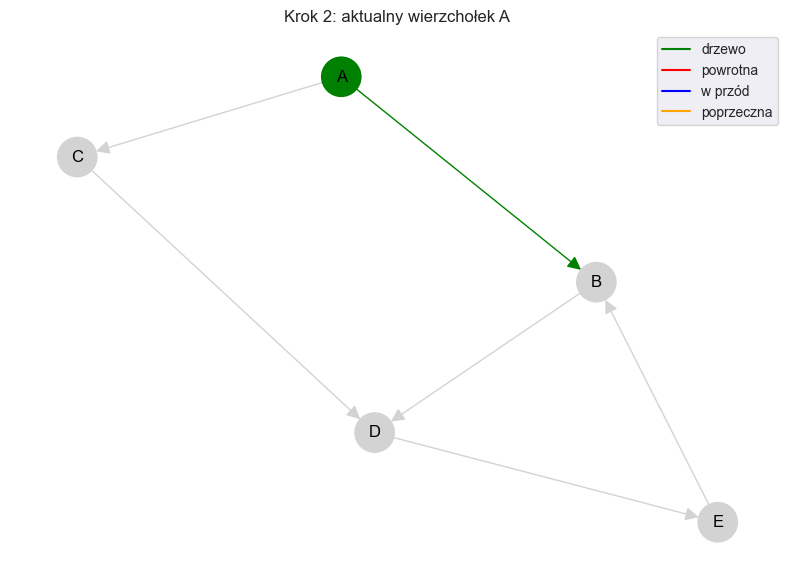

<Figure size 640x480 with 0 Axes>

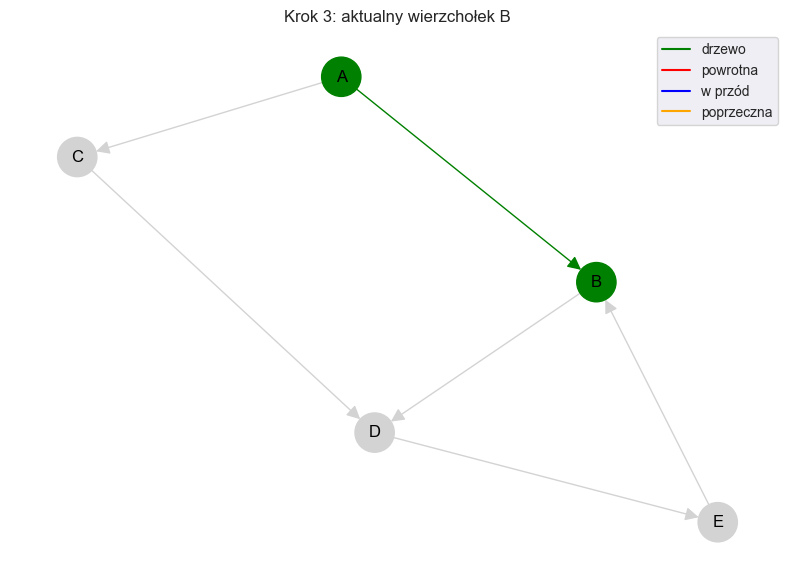

<Figure size 640x480 with 0 Axes>

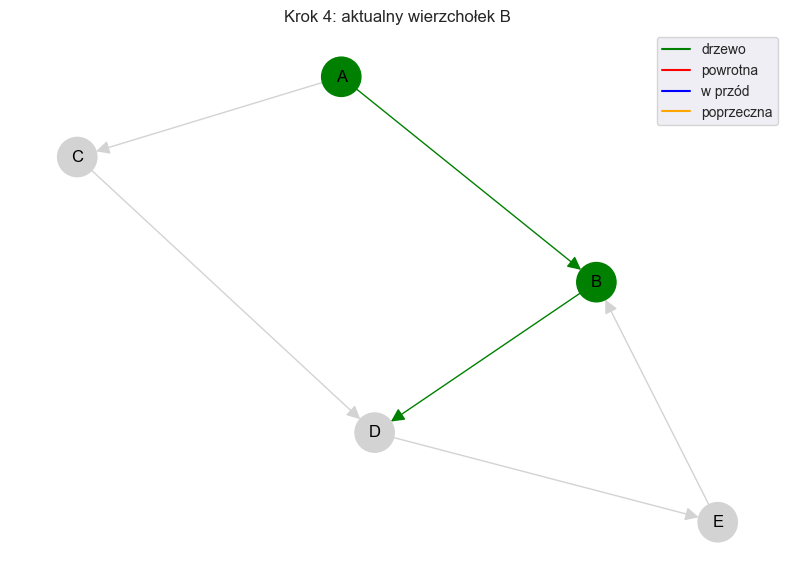

<Figure size 640x480 with 0 Axes>

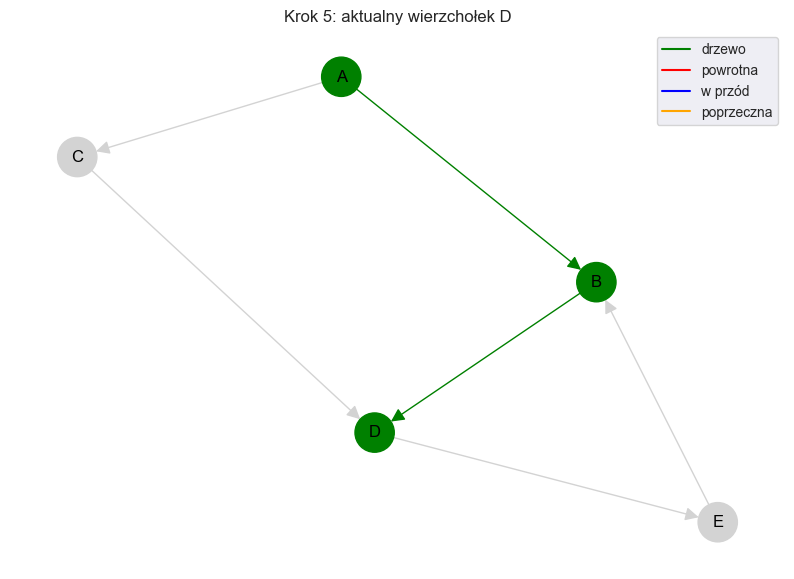

<Figure size 640x480 with 0 Axes>

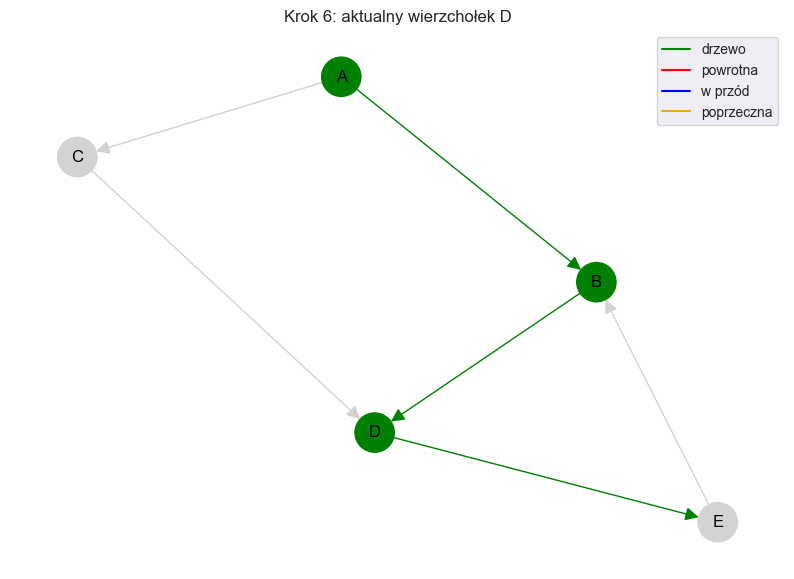

<Figure size 640x480 with 0 Axes>

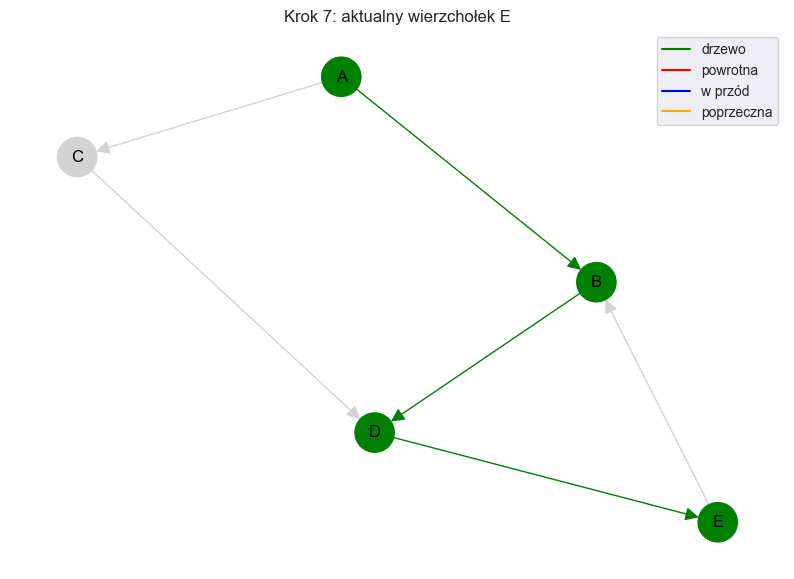

<Figure size 640x480 with 0 Axes>

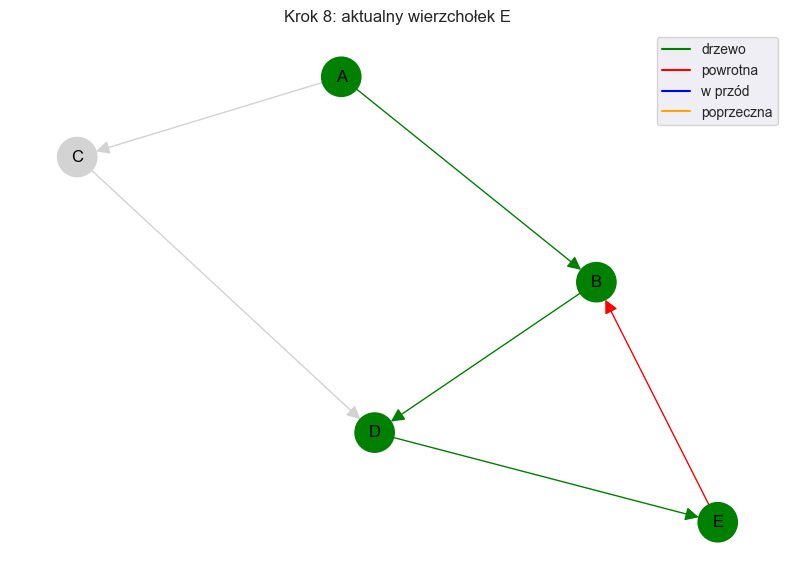

<Figure size 640x480 with 0 Axes>

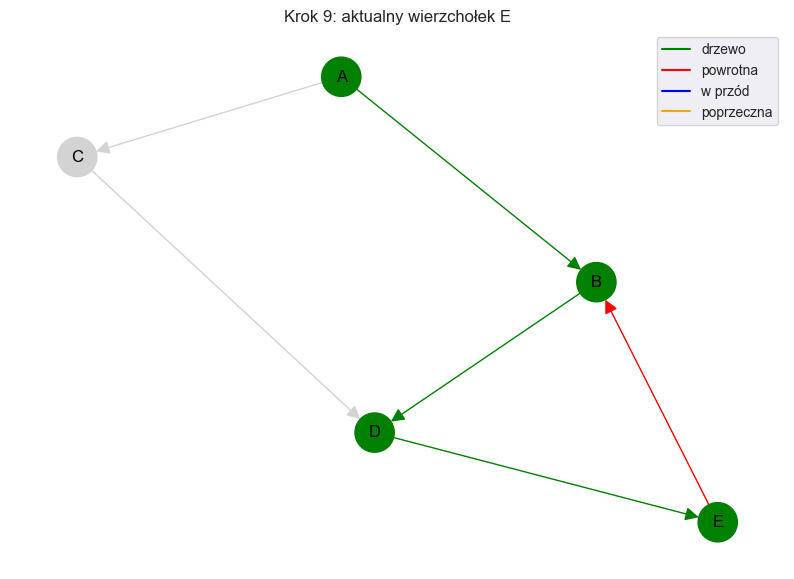

<Figure size 640x480 with 0 Axes>

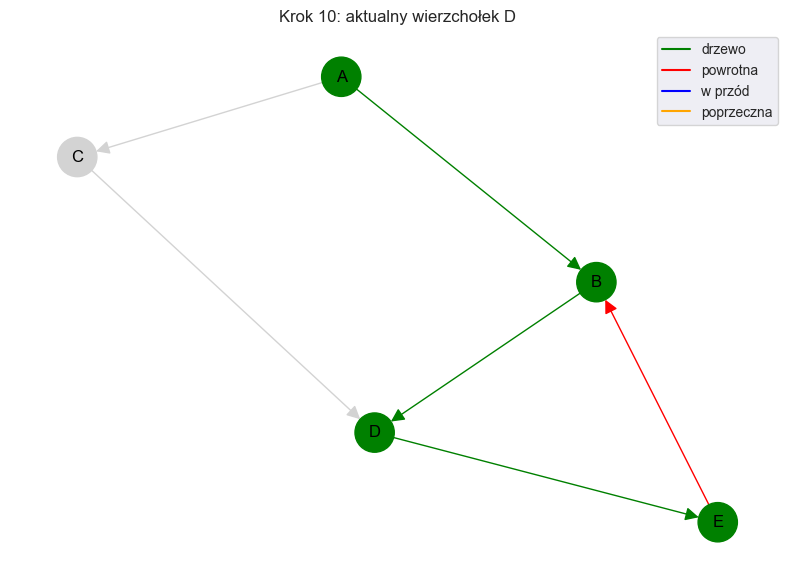

<Figure size 640x480 with 0 Axes>

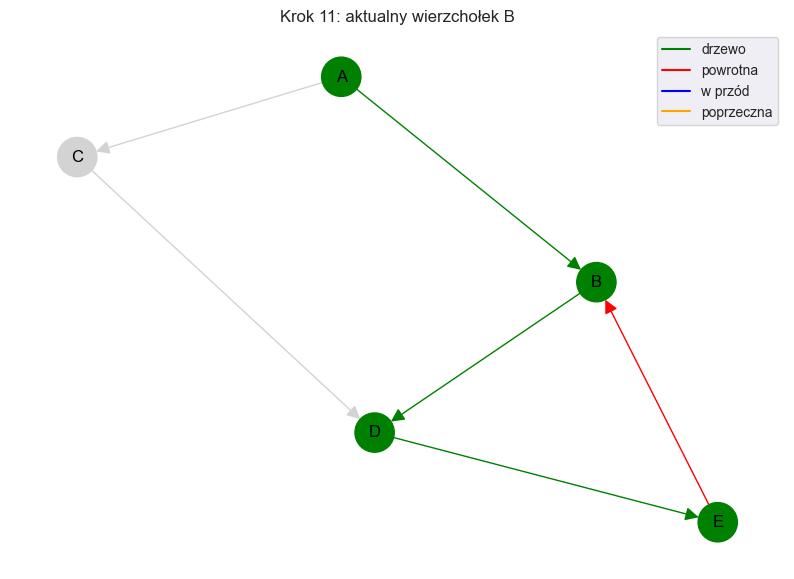

<Figure size 640x480 with 0 Axes>

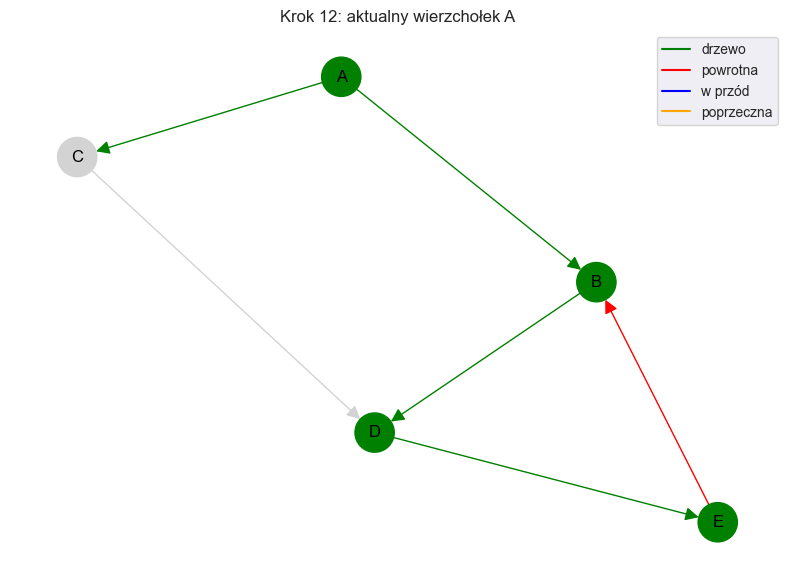

<Figure size 640x480 with 0 Axes>

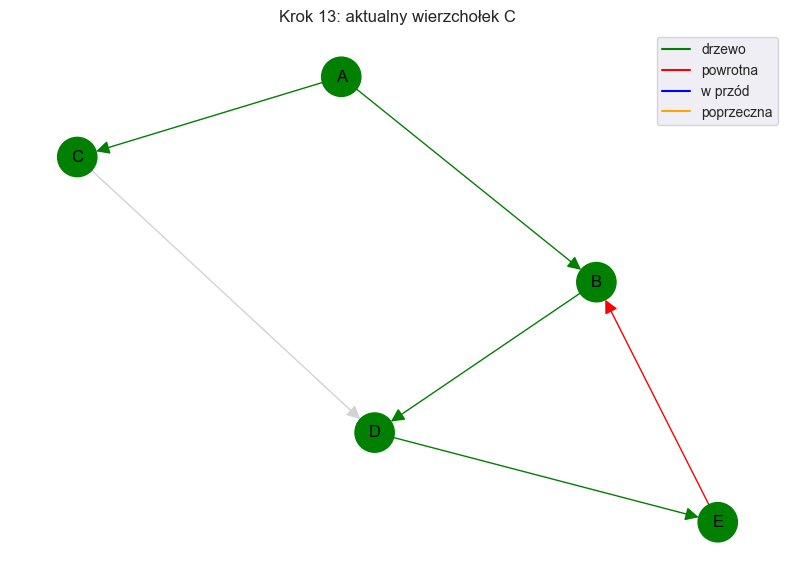

<Figure size 640x480 with 0 Axes>

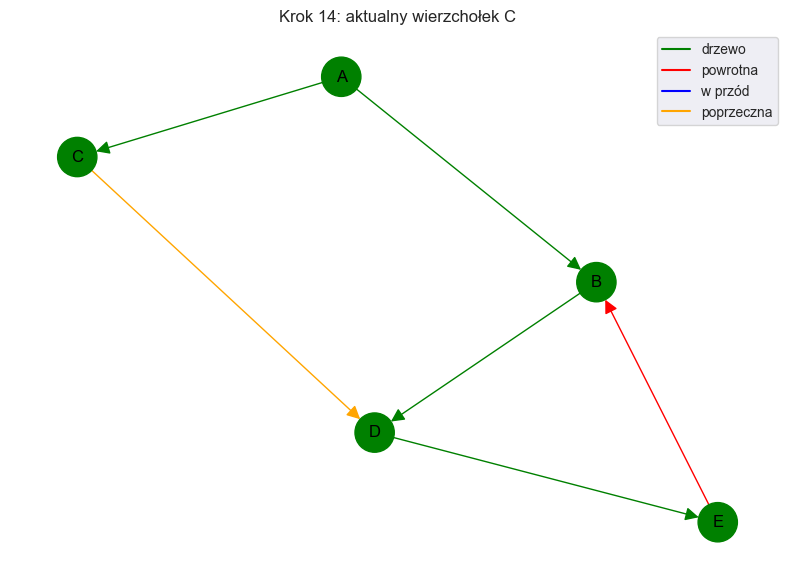

<Figure size 640x480 with 0 Axes>

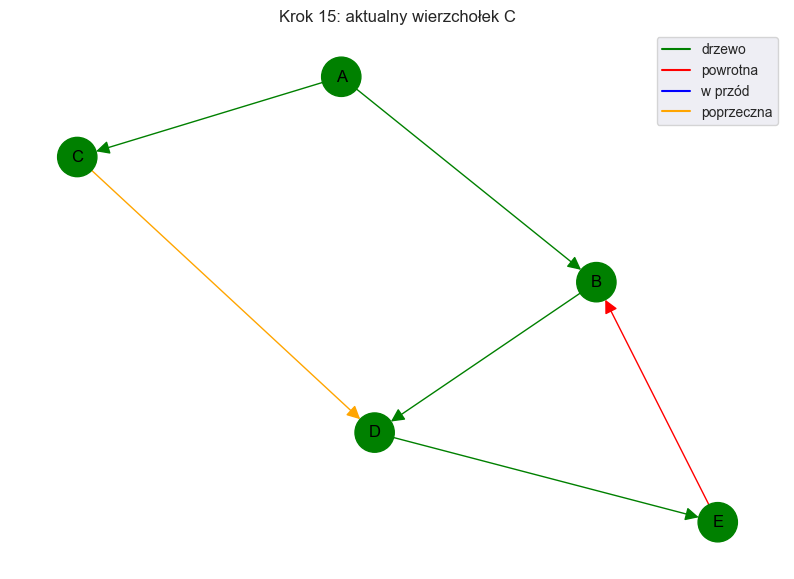

<Figure size 640x480 with 0 Axes>

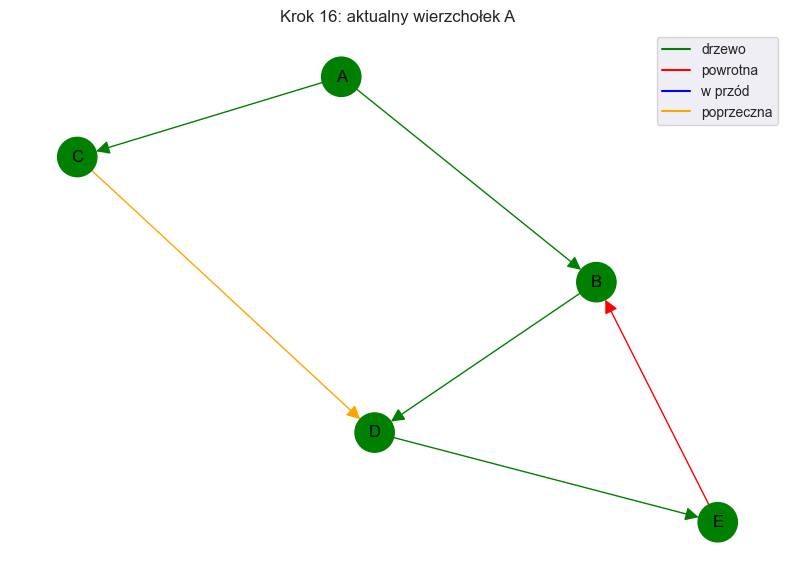

In [17]:
# Zadanie nr 3– drzewo przeszukiwań w głąb
# Uzupełnij poprzednie zadanie tak, aby kolorować krawędzie zgodnie z ich typem: drzewowa, powrotna, w przód, poprzeczna.
# Wejście: plik z grafem.
# Wyjście: wizualizacja.

import matplotlib.pyplot as plt
import networkx as nx

# graf wczytany z pliku
def wczytaj_graf_z_pliku(nazwa_pliku):
    graf = {}
    with open(nazwa_pliku, 'r') as plik:
        for linia in plik:
            dane = linia.strip().split()
            if dane:
                graf[dane[0]] = dane[1:]
    return graf

def pelne_dfs_wizualizacja_krok_po_kroku(graf):
    G = nx.DiGraph()
    for wierzcholek, sasiedzi in graf.items():
        for sasiad in sasiedzi:
            G.add_edge(wierzcholek, sasiad)

    czas = [0]
    pre = {}
    post = {}
    odwiedzone = set()
    krawedzie_typy = {}
    kroki = []  # kroki - zapisywanie kolejnych stanów do wizualizacji

    def zapisz_krok(aktualny_wierzcholek=None):
        odw = odwiedzone.copy()
        kraw = krawedzie_typy.copy()
        kroki.append((aktualny_wierzcholek, odw, kraw))

    def dfs(v):
        odwiedzone.add(v)
        czas[0] += 1
        pre[v] = czas[0]
        zapisz_krok(v)  # po odwiedzeniu wierzchołka

        for u in graf.get(v, []):
            if u not in pre:
                krawedzie_typy[(v, u)] = 'drzewowa'
                zapisz_krok(v)  # po oznaczeniu krawędzi drzewowej
                dfs(u)
            elif u not in post:
                krawedzie_typy[(v, u)] = 'powrotna'
                zapisz_krok(v)  # po oznaczeniu krawędzi powrotnej
            elif pre[v] < pre[u]:
                krawedzie_typy[(v, u)] = 'w przód'
                zapisz_krok(v)  # po oznaczeniu krawędzi w przód
            else:
                krawedzie_typy[(v, u)] = 'poprzeczna'
                zapisz_krok(v)  # po oznaczeniu krawędzi poprzecznej

        czas[0] += 1
        post[v] = czas[0]
        zapisz_krok(v)  # po zakończeniu przetwarzania wierzchołka

    for v in graf:
        if v not in odwiedzone:
            dfs(v)

    def hierarchic_layout(G):
        try:
            return nx.nx_agraph.graphviz_layout(G, prog='dot')
        except:
            return nx.spring_layout(G)

    pos = hierarchic_layout(G)

    kolory_krawedzi = {
        'drzewowa': 'green',
        'powrotna': 'red',
        'w przód': 'blue',
        'poprzeczna': 'orange'
    }

    plt.ion()
    for krok, (v, odw, kraw) in enumerate(kroki):
        plt.figure(figsize=(10, 7))
        title = f"Krok {krok + 1}"
        if v:
            title += f": aktualny wierzchołek {v}"
        plt.title(title)

        # kolory - te które odwiedzone są zielone, a reszta szara
        kolory_wierzcholkow = ['green' if node in odw else 'lightgray' for node in G.nodes()]

        edge_colors = []
        for edge in G.edges():
            etyp = kraw.get(edge, None)
            if etyp:
                edge_colors.append(kolory_krawedzi.get(etyp, 'gray'))
            else:
                edge_colors.append('lightgray')

        nx.draw(G, pos, with_labels=True, node_color=kolory_wierzcholkow,
                edge_color=edge_colors, node_size=800, arrowsize=20)
        for etyp, kolor in kolory_krawedzi.items():
            plt.plot([], [], color=kolor, label=etyp)
        plt.legend()
        plt.pause(1.5)
        plt.clf()
    plt.ioff()
    plt.close()

plik = input("Podaj nazwę pliku z grafem (np. graf2.txt): ")
graf = wczytaj_graf_z_pliku(plik)
pelne_dfs_wizualizacja_krok_po_kroku(graf)

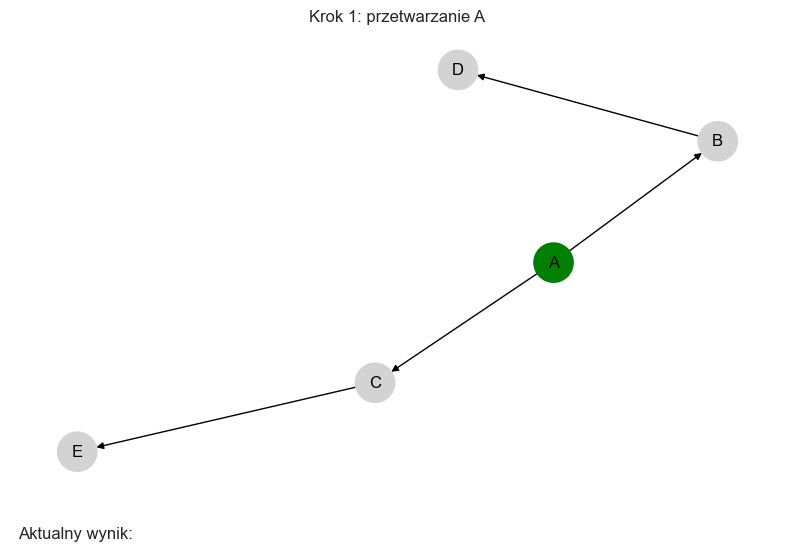

<Figure size 640x480 with 0 Axes>

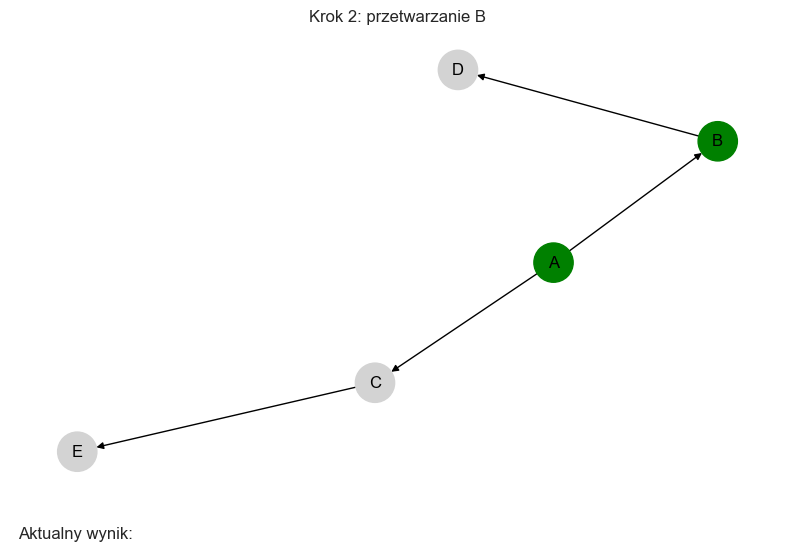

<Figure size 640x480 with 0 Axes>

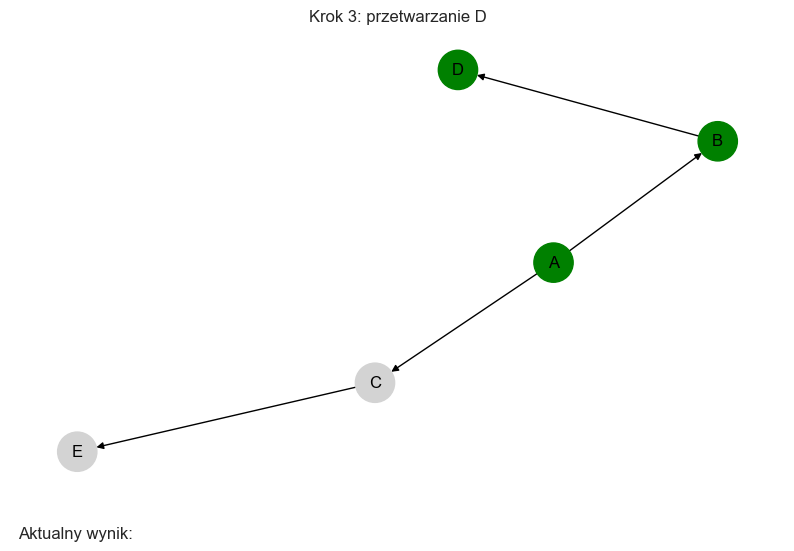

<Figure size 640x480 with 0 Axes>

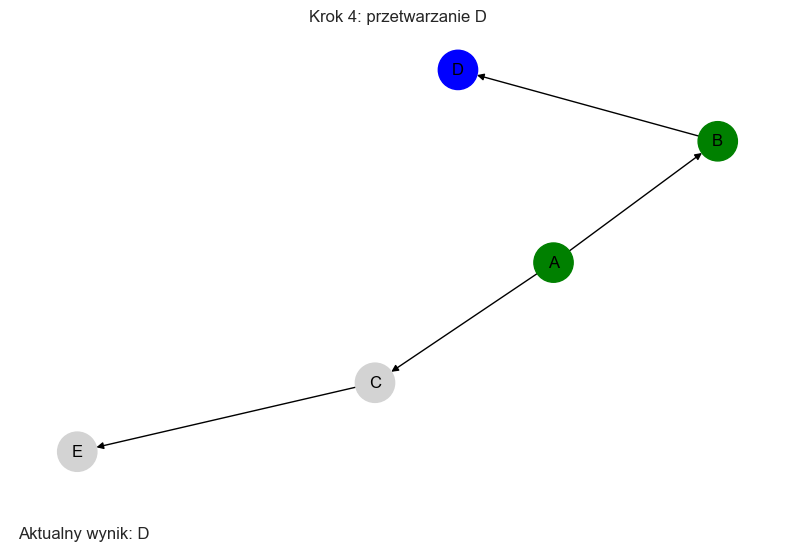

<Figure size 640x480 with 0 Axes>

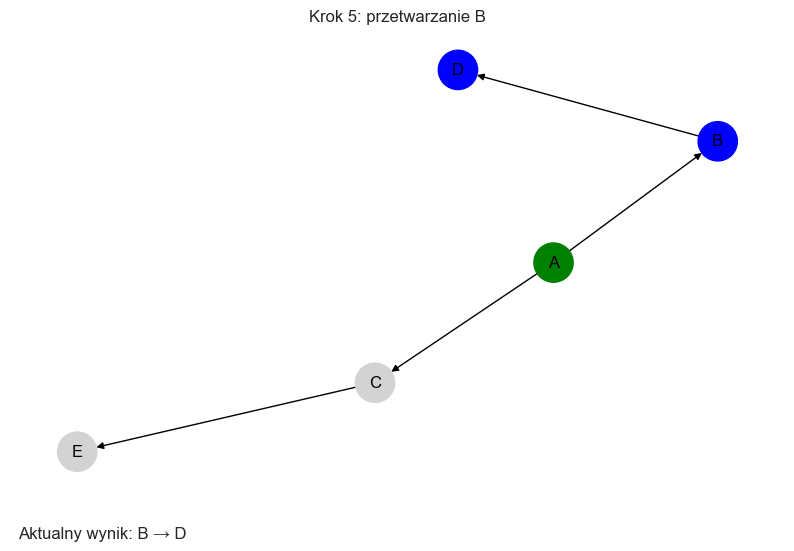

<Figure size 640x480 with 0 Axes>

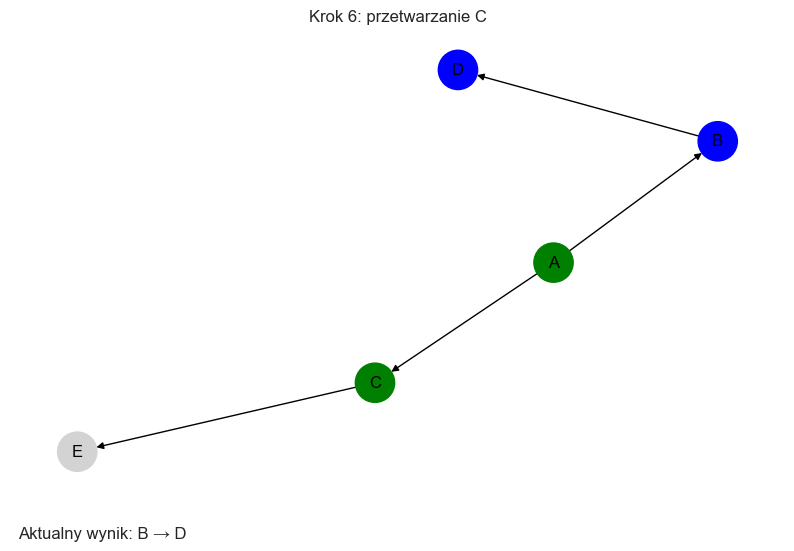

<Figure size 640x480 with 0 Axes>

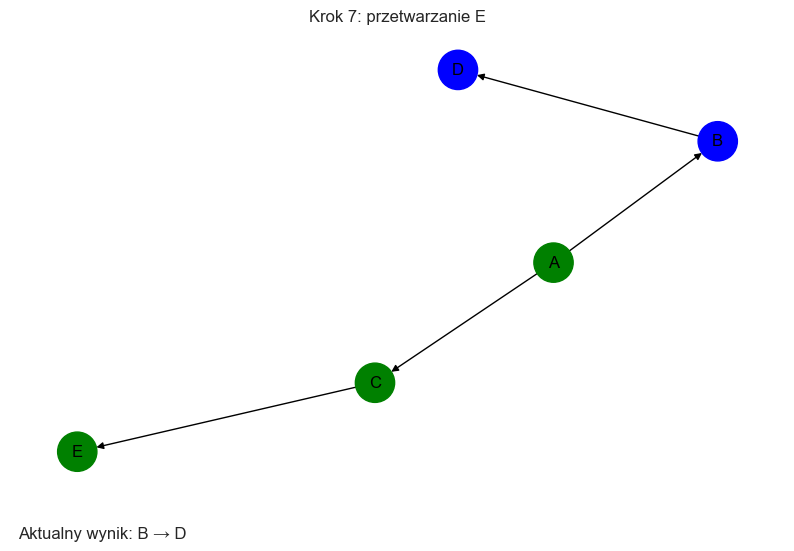

<Figure size 640x480 with 0 Axes>

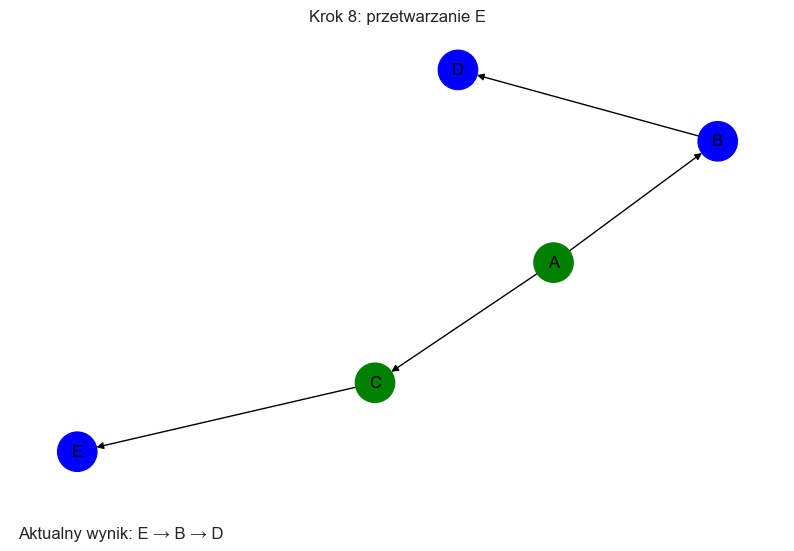

<Figure size 640x480 with 0 Axes>

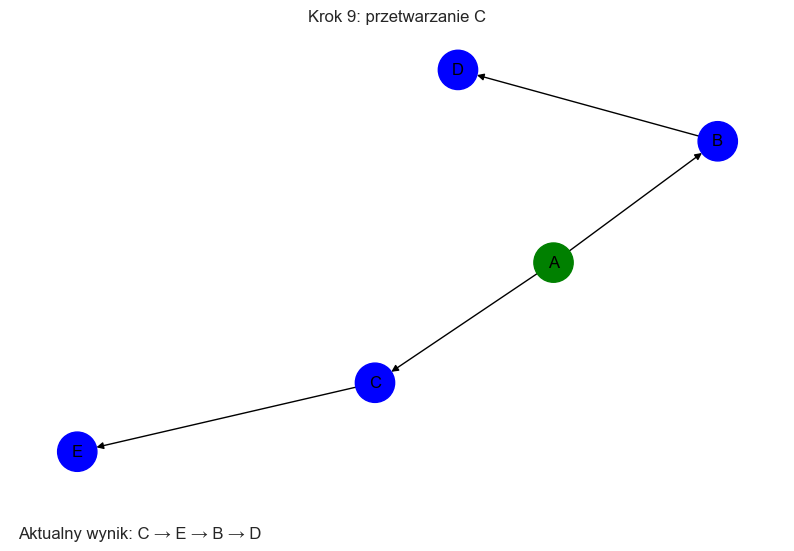

<Figure size 640x480 with 0 Axes>

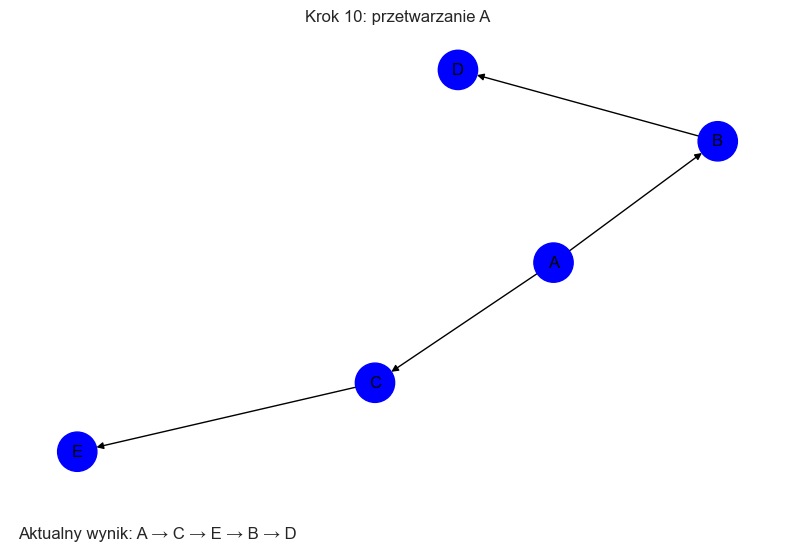

In [18]:
# Zadanie nr 4– sortowanie topologiczne
# Dla zadanego grafu wczytywanego z pliku zaimplementuj algorytm sortowania topologicznego.
# Procedurę przedstaw graficznie, krok po kroku.
# Wejście: plik z grafem.
# Wyjście: wizualizacja.

import matplotlib.pyplot as plt
import networkx as nx

def wczytaj_graf_z_pliku(nazwa_pliku):
    graf = {}
    with open(nazwa_pliku, 'r') as plik:
        for linia in plik:
            dane = linia.strip().split()
            if dane:
                graf[dane[0]] = dane[1:]
    return graf

def sortowanie_topologiczne_wizualizacja(graf):
    G = nx.DiGraph()
    for w, sasiedzi in graf.items():
        for s in sasiedzi:
            G.add_edge(w, s)

    odwiedzone = set()
    wynik = []
    kroki = []

    def zapisz_krok(aktualny=None):
        kroki.append((aktualny, odwiedzone.copy(), wynik.copy()))

    def dfs(v):
        odwiedzone.add(v)
        zapisz_krok(v)
        for u in graf.get(v, []):
            if u not in odwiedzone:
                dfs(u)
        wynik.insert(0, v)  # dodajemy na początek listy
        zapisz_krok(v)

    for v in graf:
        if v not in odwiedzone:
            dfs(v)

    def hierarchic_layout(G):
        try:
            return nx.nx_agraph.graphviz_layout(G, prog='dot')
        except:
            return nx.spring_layout(G)

    pos = hierarchic_layout(G)

    plt.ion()
    for i, (v, odw, wyn) in enumerate(kroki):
        plt.figure(figsize=(10, 6))
        tytul = f"Krok {i + 1}"
        if v:
            tytul += f": przetwarzanie {v}"
        plt.title(tytul)

        kolory = []
        for node in G.nodes():
            if node in wyn:
                kolory.append('blue') # wierzchołki w wyniku
            elif node in odw:
                kolory.append('green') # wierzchołki odiwedzone
            else:
                kolory.append('lightgray') # wierzchołki nieodwiedzone

        nx.draw(G, pos, with_labels=True, node_color=kolory, node_size=800, arrows=True)
        # Pokazujemy stan listy topologicznej
        plt.text(0.01, -0.1, f"Aktualny wynik: {' → '.join(wyn)}", transform=plt.gca().transAxes, fontsize=12)
        plt.pause(1.5)
        plt.clf()
    plt.ioff()
    plt.close()

plik = input("Podaj nazwę pliku z grafem (np. graf1.txt): ")
graf = wczytaj_graf_z_pliku(plik)
sortowanie_topologiczne_wizualizacja(graf)

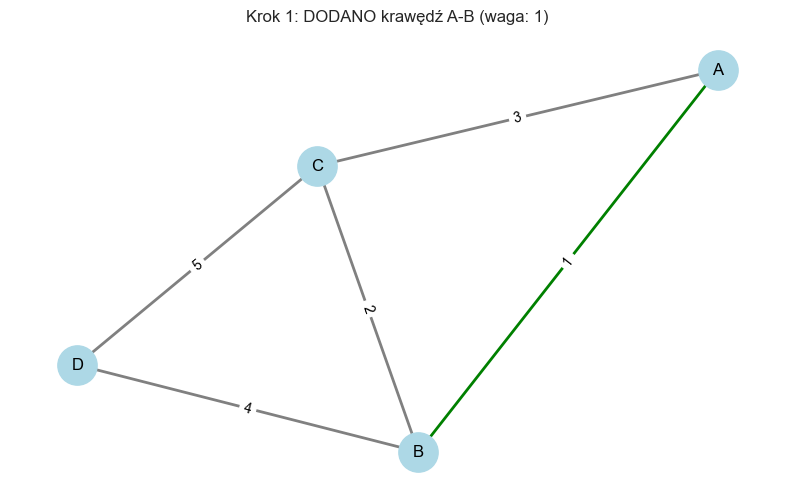

<Figure size 640x480 with 0 Axes>

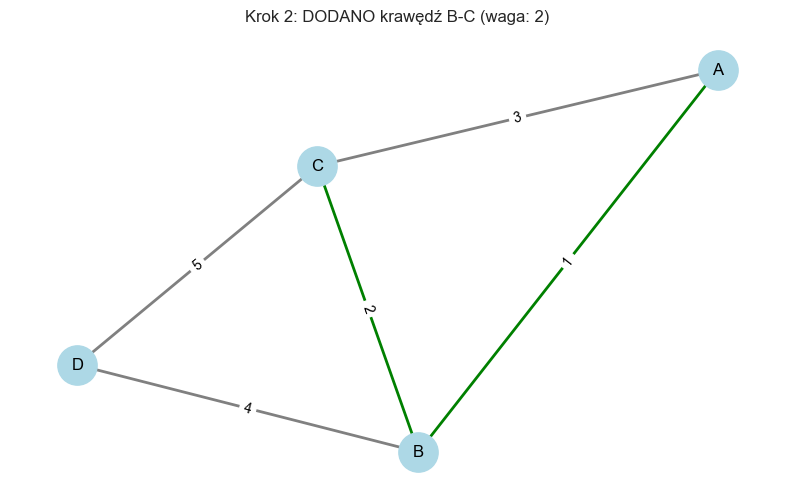

<Figure size 640x480 with 0 Axes>

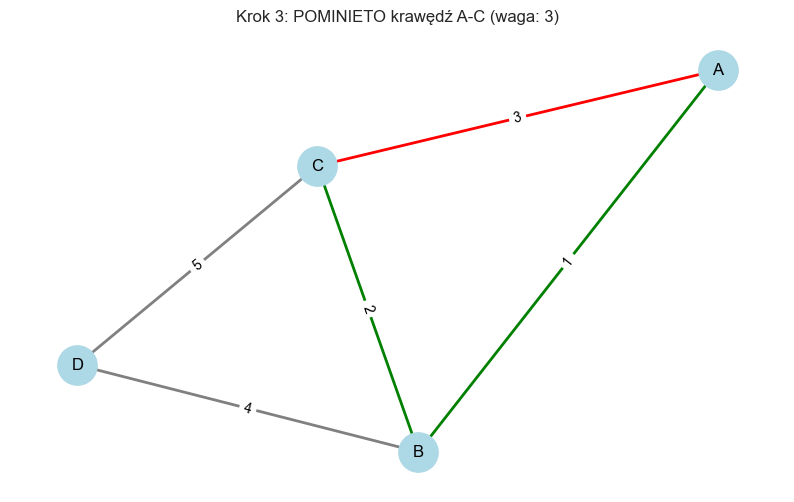

<Figure size 640x480 with 0 Axes>

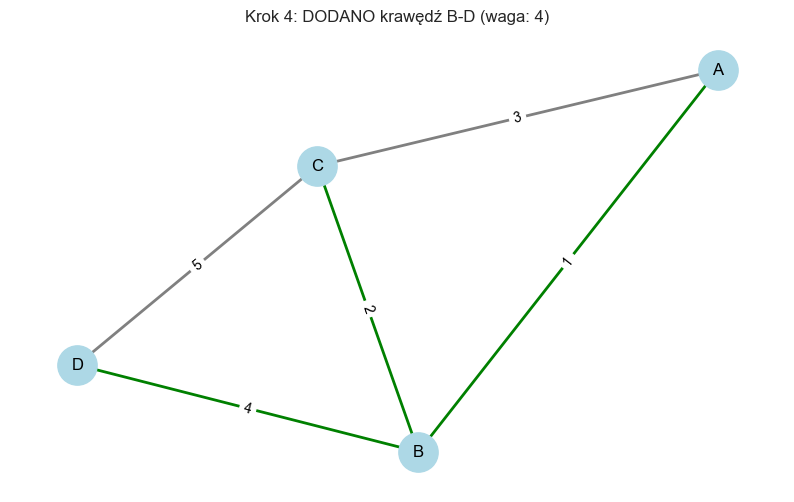

<Figure size 640x480 with 0 Axes>

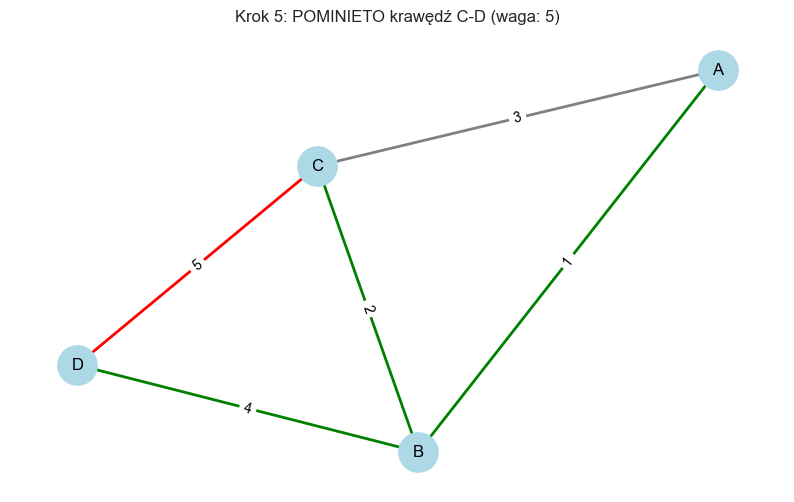

In [19]:
#  Zadanie nr 5– minimalne drzewo rozpinającego
#  Dla zadanego grafu wczytywanego z pliku zaimplementuj algorytm Kruskala (generacji minimalnego drzewa rozpinającego).
#  Wimplementacji wykorzystaj zbiory rozłączne.
#  Procedurę przedstaw graficznie, krok po kroku.
#  Wejście: plik z grafem, początkowy wierzchołek.
#  Wyjście: wizualizacja


import matplotlib.pyplot as plt
import networkx as nx

# zbiory rozłączne
class UnionFind:
    def __init__(self):
        self.parent = {}

    def find(self, x):
        if self.parent.setdefault(x, x) != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        self.parent[self.find(x)] = self.find(y)

def wczytaj_graf_z_pliku(nazwa_pliku):
    krawedzie = []
    with open(nazwa_pliku, 'r') as plik:
        for linia in plik:
            dane = linia.strip().split()
            if len(dane) == 3:
                u, v, waga = dane
                krawedzie.append((u, v, int(waga)))
    return krawedzie

def kruskal_wizualizacja(krawedzie):
    G = nx.Graph()
    for u, v, w in krawedzie:
        G.add_edge(u, v, weight=w)

    # algorytm Kruskla
    uf = UnionFind()
    krawedzie_posortowane = sorted(krawedzie, key=lambda x: x[2])
    mst = []
    kroki = []

    for u, v, w in krawedzie_posortowane:
        if uf.find(u) != uf.find(v):
            uf.union(u, v)
            mst.append((u, v))
            kroki.append(((u, v, w), 'dodano', list(mst)))
        else:
            kroki.append(((u, v, w), 'pominieto', list(mst)))

    pos = nx.spring_layout(G, seed=42)

    plt.ion()
    for i, (kraw, akcja, mst_krawedzie) in enumerate(kroki):
        plt.figure(figsize=(10, 6))
        u, v, w = kraw
        plt.title(f"Krok {i+1}: {akcja.upper()} krawędź {u}-{v} (waga: {w})")

        edge_colors = []
        edge_styles = []
        for edge in G.edges():
            if edge in mst_krawedzie or (edge[1], edge[0]) in mst_krawedzie:
                edge_colors.append('green')
                edge_styles.append('solid')
            elif edge == (u, v) or edge == (v, u):
                if akcja == 'pominieto':
                    edge_colors.append('red')
                else:
                    edge_colors.append('green')
                edge_styles.append('solid')
            else:
                edge_colors.append('gray')
                edge_styles.append('dashed')

        weights = nx.get_edge_attributes(G, 'weight')
        nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800,
                edge_color=edge_colors, style='solid', width=2)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=weights)
        plt.pause(1.5)
        plt.clf()
    plt.ioff()
    plt.close()

plik = input("Podaj nazwę pliku z grafem (np. graf3.txt): ")
krawedzie = wczytaj_graf_z_pliku(plik)
kruskal_wizualizacja(krawedzie)